# Notebook 2 — Baseline Convolutional Neural Network (CNN)

## Satellite Image Land-Use Classification & Temporal Change Detection

This notebook develops a baseline Convolutional Neural Network (CNN) for
land-use classification using the prepared EuroSAT dataset.

The objective is to establish a reference model by training a CNN from scratch
and evaluating its performance on unseen validation and test data. The results
obtained in this notebook serve as a baseline for comparison with the transfer
learning approach implemented in the subsequent notebook.

The workflow includes model construction, training, validation, performance
evaluation, and visualization of the classification results.

## Import Required Libraries

This section imports the libraries required to build, train, and evaluate the
baseline Convolutional Neural Network (CNN).

The imported modules provide functionality for:

- Numerical computations and data visualization
- Building neural network architectures with PyTorch
- Model optimization and loss computation
- Loading and batching the EuroSAT dataset
- Evaluating classification performance using F1-score metrics

The computation device is also configured to use a GPU when available,
otherwise the model is executed on the CPU.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Dataset Preparation

### Reconstruct the Data Pipeline

The data preparation pipeline from **Notebook 1** is recreated to ensure
consistency across all experiments.

The same preprocessing operations, approximate spatial block split, and
DataLoader configuration are applied so that the baseline CNN is trained and
evaluated on exactly the same training, validation, and test datasets.

Reusing the identical data pipeline enables a fair comparison between the
baseline CNN and the transfer learning model developed in the subsequent
notebook.

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

dataset = datasets.EuroSAT(root="./data", download=True, transform=transform)
class_names = dataset.classes

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

train_indices, val_indices, test_indices = [], [], []

for class_idx in range(len(class_names)):
    class_indices = [i for i, label in enumerate(dataset.targets) if label == class_idx]
    n = len(class_indices)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    train_indices.extend(class_indices[:train_end])
    val_indices.extend(class_indices[train_end:val_end])
    test_indices.extend(class_indices[val_end:])

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset), "| Val size:", len(val_dataset))

100%|██████████| 94.3M/94.3M [00:00<00:00, 334MB/s]


Train size: 18900 | Val size: 4050


### Define the Baseline CNN

A lightweight Convolutional Neural Network (CNN) is designed to establish a
baseline for the land-use classification task.

The network consists of three convolutional blocks, where each block applies a
convolution operation followed by a ReLU activation function and max-pooling to
progressively extract higher-level spatial features while reducing the spatial
dimensions of the input.

The extracted feature maps are then flattened and passed through a fully
connected classifier to predict one of the ten EuroSAT land-use classes.

In [3]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64x64 -> 32x32

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16 -> 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = BaselineCNN(num_classes=len(class_names)).to(device)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


### Model Training

The baseline CNN is trained using a standard supervised learning procedure.

For each training epoch, the model performs a forward pass to generate class
predictions, computes the classification loss, and updates its parameters
through backpropagation and gradient-based optimization.

Training and validation losses are recorded after every epoch to monitor the
learning process, evaluate model convergence, and identify potential
overfitting during training.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 5

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # --- training ---
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- validation ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss={epoch_train_loss:.4f} | val_loss={epoch_val_loss:.4f}")

Epoch 1/5 | train_loss=1.1584 | val_loss=0.8102
Epoch 2/5 | train_loss=0.7281 | val_loss=0.6405
Epoch 3/5 | train_loss=0.6207 | val_loss=0.6170
Epoch 4/5 | train_loss=0.5348 | val_loss=0.5804
Epoch 5/5 | train_loss=0.4611 | val_loss=0.4588


### Training and Validation Loss

The training and validation losses are visualized across all epochs to monitor
the learning behavior of the baseline CNN.

Comparing these curves helps assess model convergence, training stability, and
whether the model begins to overfit or underfit during the training process.

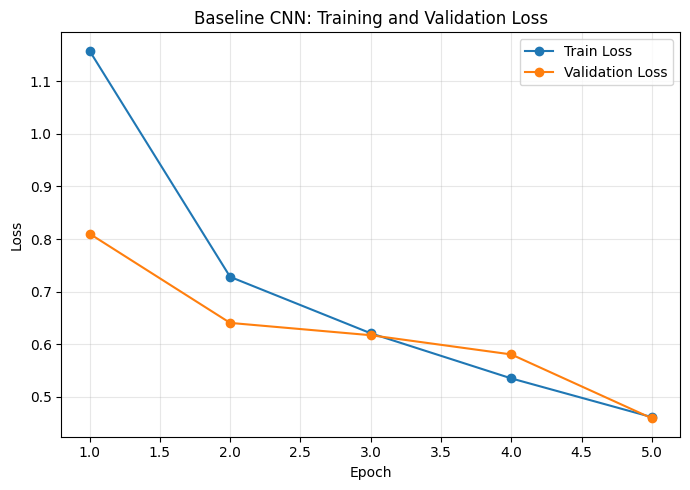

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation

The trained baseline CNN is evaluated on the validation dataset to measure its
classification performance across all land-use categories.

Performance is reported using per-class F1-scores, which provide a balanced
assessment of precision and recall for each class. These results establish the
baseline performance and serve as a reference for comparison with the transfer
learning model developed in the next notebook.

In [8]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

per_class_f1 = f1_score(all_labels, all_preds, average=None)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print("Per-class F1:")
for name, score in zip(class_names, per_class_f1):
    print(f"{name:15s}: {score:.3f}")

print(f"\nMacro F1: {macro_f1:.3f}")

Per-class F1:
AnnualCrop     : 0.857
Forest         : 0.923
HerbaceousVegetation: 0.790
Highway        : 0.645
Industrial     : 0.929
Pasture        : 0.794
PermanentCrop  : 0.739
Residential    : 0.946
River          : 0.708
SeaLake        : 0.930

Macro F1: 0.826


## Conclusion

- Developed and trained a three-layer Convolutional Neural Network (CNN) as a
  baseline model for satellite land-use classification.
- Evaluated the learning process using training and validation loss curves to
  monitor convergence and generalization performance.
- Measured the model's classification performance using per-class F1-scores
  and the Macro F1-score on the validation dataset.
- The results obtained in this notebook establish the baseline performance for
  comparison with the transfer learning approach implemented in the subsequent
  notebook.